In [25]:
import networkx as nx
from networkx.readwrite import json_graph
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
with open(f'../data/ka2_graphs/ka2_mobility_network_all.json', 'r') as f:
    data = json.load(f)
    G = json_graph.node_link_graph(data)

In [42]:
geog_regions = ['West','North','Central/East','South','Other' ]
sending_dict = {g : {gg : 0 for gg in geog_regions} for g in geog_regions}

region_map = {node : data['geographical_cultural_region'] for node,data in G.nodes(data=True)}

In [43]:
for sender, receiver, data in G.edges(data=True):
    # print(sender, receiver, data)
    r1, r2 = region_map[sender], region_map[receiver]
    sending_dict[r1][r2] += data['weight']

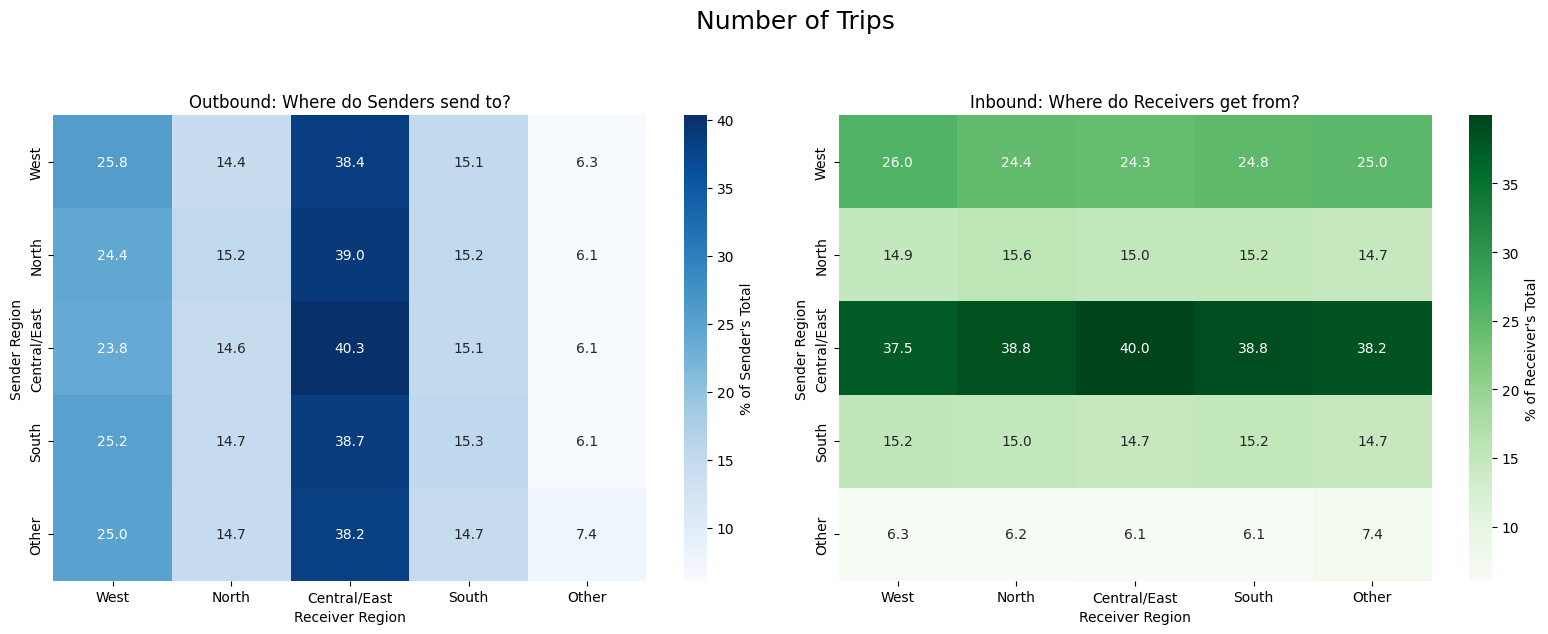

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data
df = pd.DataFrame(sending_dict).T

# Calculate Row Percentages (Sender's perspective - rows sum to 100)
df_row_pct = df.div(df.sum(axis=1), axis=0).fillna(0) * 100

# Calculate Column Percentages (Receiver's perspective - cols sum to 100)
df_col_pct = df.div(df.sum(axis=0), axis=1).fillna(0) * 100

# 2. Set up a side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Number of Trips", fontsize=18, y=1.05)
# Plot 1: Sender's Perspective (Row Percentages)
sns.heatmap(df_row_pct, annot=True, fmt=".1f", cmap="Blues", 
            cbar_kws={'label': '% of Sender\'s Total'}, ax=axes[0])
axes[0].set_title("Outbound: Where do Senders send to?")
axes[0].set_ylabel("Sender Region")
axes[0].set_xlabel("Receiver Region")

# Plot 2: Receiver's Perspective (Column Percentages)
sns.heatmap(df_col_pct, annot=True, fmt=".1f", cmap="Greens", 
            cbar_kws={'label': '% of Receiver\'s Total'}, ax=axes[1])
axes[1].set_title("Inbound: Where do Receivers get from?")
axes[1].set_ylabel("Sender Region")
axes[1].set_xlabel("Receiver Region")

plt.tight_layout()
plt.savefig("../data/plots/send_rec_heatmap_output_trips.png", dpi=300, bbox_inches='tight')
plt.show()

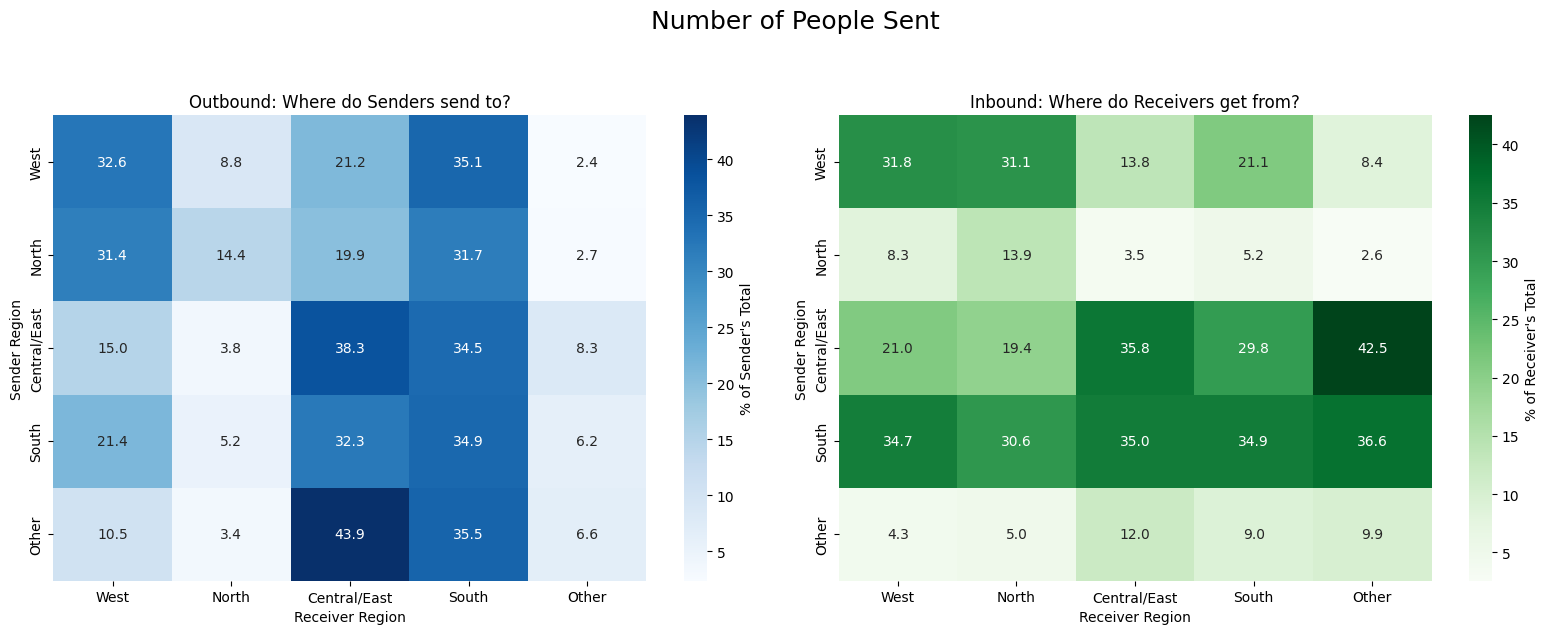

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data
df = pd.DataFrame(sending_dict).T

# Calculate Row Percentages (Sender's perspective - rows sum to 100)
df_row_pct = df.div(df.sum(axis=1), axis=0).fillna(0) * 100

# Calculate Column Percentages (Receiver's perspective - cols sum to 100)
df_col_pct = df.div(df.sum(axis=0), axis=1).fillna(0) * 100

# 2. Set up a side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Number of People Sent", fontsize=18, y=1.05)

# Plot 1: Sender's Perspective (Row Percentages)
sns.heatmap(df_row_pct, annot=True, fmt=".1f", cmap="Blues", 
            cbar_kws={'label': '% of Sender\'s Total'}, ax=axes[0])
axes[0].set_title("Outbound: Where do Senders send to?")
axes[0].set_ylabel("Sender Region")
axes[0].set_xlabel("Receiver Region")

# Plot 2: Receiver's Perspective (Column Percentages)
sns.heatmap(df_col_pct, annot=True, fmt=".1f", cmap="Greens", 
            cbar_kws={'label': '% of Receiver\'s Total'}, ax=axes[1])
axes[1].set_title("Inbound: Where do Receivers get from?")
axes[1].set_ylabel("Sender Region")
axes[1].set_xlabel("Receiver Region")

plt.tight_layout()
plt.savefig("../data/plots/send_rec_heatmap_output_people.png", dpi=300, bbox_inches='tight')
plt.show()

# Adding GDP


In [45]:
df = pd.read_csv('../data/country_extra_data.csv')

# Map of countries to their approximate Nominal GDP per capita
gdp_mapping = {
    "GE - Georgia": 8.284,
    "LU - Luxembourg": 137.516,
    "RO - Romania": 20.072,
    "PT - Portugal": 28.844,
    "SE - Sweden": 57.723,
    "NO - Norway": 86.810,
    "UK - United Kingdom": 52.637,
    "AT - Austria": 56.833,
    "CY - Cyprus": 38.654,
    "SI - Slovenia": 34.089,
    "FI - Finland": 53.189,
    "BE - Belgium": 55.723,
    "MT - Malta": 42.347,
    "BA - Bosnia and Herzegovina": 8.957,
    "BG - Bulgaria": 17.412,
    "LV - Latvia": 23.367,
    "RS - Serbia": 13.524,
    "SK - Slovakia": 26.148,
    "FR - France": 46.150,
    "HR - Croatia": 23.932,
    "TR - Turkey": 15.473,
    "EL - Greece": 24.752,
    "MK - The Republic of North Macedonia": 9.310,
    "ME - Montenegro": 12.936,
    "IT - Italy": 40.226,
    "DE - Germany": 55.800,
    "IS - Iceland": 82.704,
    "HU - Hungary": 23.310,
    "XK - Kosovo * UN resolution": 7.299,
    "LY - Libya": 6.318,
    "IE - Ireland": 107.316,
    "NL - Netherlands": 68.219,
    "LT - Lithuania": 29.386,
    "EE - Estonia": 31.170,
    "CZ - Czechia": 31.707,
    "ES - Spain": 35.298,
    "DK - Denmark": 71.852,
    "PL - Poland": 25.023,
    "LI - Liechtenstein": 207.973
}

# Add the new column by mapping the dictionary to the Country column
df['GDP_per_capita'] = df['Country'].map(gdp_mapping)

print(df.head())

           Country Language_Family   Economic_Family  \
0     GE - Georgia              14   Emerging_Market   
1  LU - Luxembourg           1,3,4  Advanced_Economy   
2     RO - Romania               4   Emerging_Market   
3    PT - Portugal               4  Advanced_Economy   
4      SE - Sweden             1,2  Advanced_Economy   

  Geographical_Cultural_Region      lat      lon  GDP_per_capita  
0                        Other  42.3154  43.3569           8.284  
1                         West  49.8153   6.1296         137.516  
2                 Central/East  45.9432  24.9668          20.072  
3                        South  39.3999  -8.2245          28.844  
4                        North  60.1282  18.6435          57.723  


In [46]:
df.to_csv('../data/country_extra_data.csv')

# Add new value to each node in graph

In [47]:
# Assuming your 'years' list is already set up
# years = list(df['Mobility Year'].unique()) + ['all']

# If you have a dictionary mapping node IDs to your new custom data, 
# you might define it here. For example:
# custom_node_data = {"DE - Germany": {"GDP": 4456.0, "Status": "Active"}, ...}
years = ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', 'all']
for year in years:
    file_path = f'../data/ka2_graphs/ka2_mobility_network_{year}.json'
    
    # 1. Read the graph from the file
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"File not found: {file_path}. Skipping...")
        continue
        
    # 2. Convert JSON data back to a NetworkX Graph
    G = json_graph.node_link_graph(data)
    
    # 3. Iterate through nodes and add custom data
    for node, node_data in G.nodes(data=True):
        node_data['gdp_per_capita'] = gdp_mapping[node]
        
    # 4. Convert the updated graph back to JSON format
    updated_data = json_graph.node_link_data(G)
    
    # 5. Save it back out (overwriting the original file)
    with open(file_path, 'w') as f:
        json.dump(updated_data, f, indent=2)
        
    print(f"Successfully updated nodes in {file_path}")

Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_2014.json
Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_2015.json
Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_2016.json
Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_2017.json
Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_2018.json
Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_2019.json
Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_2020.json
Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_2021.json
Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_2022.json
Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_2023.json
Successfully updated nodes in ../data/ka2_graphs/ka2_mobility_network_all.json


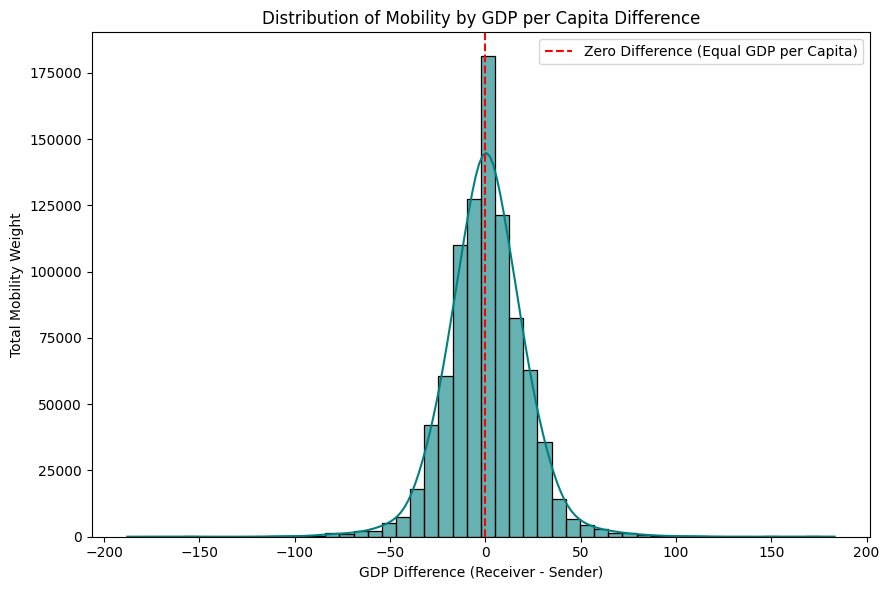

,sender,receiver,weight,gdp_diff
0,GE - Georgia,FR - France,1,37.866
1,LU - Luxembourg,FI - Finland,21,-84.327
2,LU - Luxembourg,TR - Turkey,8,-122.043
3,LU - Luxembourg,FR - France,96,-91.366
4,LU - Luxembourg,IT - Italy,99,-97.290
...,...,...,...,...
1085,LI - Liechtenstein,RO - Romania,1,-187.901
1086,LI - Liechtenstein,UK - United Kingdom,1,-155.336
1087,LI - Liechtenstein,BE - Belgium,52,-152.250
1088,LI - Liechtenstein,EL - Greece,32,-183.221


In [ ]:
def plot_gdp_difference_from_graph(G: nx.Graph, gdp_key: str = 'gdp_per_capita') -> pd.DataFrame:
    """
    Extracts GDP data from a graph object and plots the distribution 
    of edge weights based on the GDP difference between nodes.
    """
    
    # 1. Extract edge weights and node GDPs into a list
    edge_records = []
    
    for sender, receiver, data in G.edges(data=True):
        # Retrieve GDP from node attributes (defaults to None if missing)
        sender_gdp = G.nodes[sender].get(gdp_key)
        receiver_gdp = G.nodes[receiver].get(gdp_key)
        weight = data.get('weight', 1) # Default weight to 1 if not specified
        
        # Only process edges where both nodes have GDP data
        if sender_gdp is not None and receiver_gdp is not None:
            gdp_diff = receiver_gdp - sender_gdp
            edge_records.append({
                "sender": sender,
                "receiver": receiver,
                "weight": weight,
                "gdp_diff": gdp_diff
            })
            
    # 2. Convert to a Pandas DataFrame
    edges_df = pd.DataFrame(edge_records)
    
    # Safety check in case no data was found
    if edges_df.empty:
        print(f"Error: No edges found with valid '{gdp_key}' data on both nodes.")
        return edges_df

    # 3. Plot the data
    fig, ax = plt.subplots(figsize=(9, 6))
    
    sns.histplot(
        data=edges_df, 
        x="gdp_diff", 
        weights="weight", 
        bins=50, 
        kde=True, 
        color="teal",
        alpha=0.6,
        ax=ax
    )
    
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero Difference (Equal GDP per Capita)")
    
    ax.set_title("Distribution of Mobility by GDP per Capita Difference")
    ax.set_xlabel("GDP Difference (Receiver - Sender)")
    ax.set_ylabel("Total Mobility Weight")
    ax.legend()
    
    plt.tight_layout()
    # plt.savefig("gdp_difference_distribution.png", dpi=300)
    plt.savefig("../data/plots/gdp_difference_distribution.png", dpi=300, bbox_inches='tight')

    plt.show()
    
    # Return the dataframe in case you want to inspect the extracted data
    # return edges_df

with open(f'../data/ka2_graphs/ka2_mobility_network_all.json', 'r') as f:
    data = json.load(f)
    G = json_graph.node_link_graph(data)

plot_gdp_difference_from_graph(G)

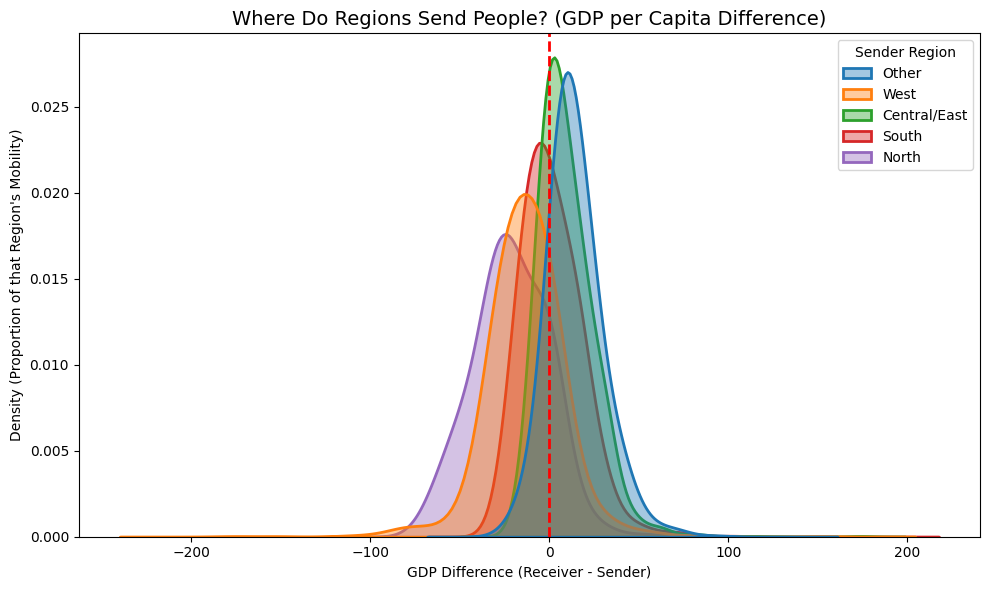

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

def plot_gdp_diff_by_region(G: nx.Graph, gdp_key: str = 'gdp_per_capita', region_key: str = 'Geographical_Cultural_Region'):
    """
    Plots the distribution of GDP differences, split by the Sender's region.
    """
    edge_records = []
    
    # 1. Extract the data from the graph
    for sender, receiver, data in G.edges(data=True):
        sender_gdp = G.nodes[sender].get(gdp_key)
        receiver_gdp = G.nodes[receiver].get(gdp_key)
        sender_region = G.nodes[sender].get(region_key)
        weight = data.get('weight', 1)
        
        if sender_gdp is not None and receiver_gdp is not None and sender_region is not None:
            edge_records.append({
                "sender": sender,
                "sender_region": sender_region,
                "weight": weight,
                "gdp_diff": receiver_gdp - sender_gdp
            })
            
    edges_df = pd.DataFrame(edge_records)
    
    if edges_df.empty:
        print("Error: No edges found with valid GDP and Region data.")
        return edges_df

    # 2. Set up the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 3. Plot a weighted KDE for each region
    # common_norm=False ensures each region's curve is scaled independently, 
    # so smaller regions aren't visually swallowed by larger ones.
    sns.kdeplot(
        data=edges_df, 
        x="gdp_diff", 
        hue="sender_region", 
        weights="weight",
        fill=True, 
        common_norm=False, 
        alpha=0.4,
        linewidth=2,
        palette="tab10",
        ax=ax
    )
    
    # 4. Add the zero-difference baseline
    ax.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Difference")
    
    ax.set_title("Where Do Regions Send People? (GDP per Capita Difference)", fontsize=14)
    ax.set_xlabel("GDP Difference (Receiver - Sender)")
    ax.set_ylabel("Density (Proportion of that Region's Mobility)")
    
    # Clean up the legend
    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles=handles, labels=labels, title="Sender Region", loc="upper right")
    sns.move_legend(ax, "upper right", title="Sender Region")
    
    plt.tight_layout()
    plt.savefig("../data/plots/gdp_diff_by_region.png", dpi=300, bbox_inches='tight')

    plt.show()
    
    # return edges_df

# Example execution:
extracted_regional_df = plot_gdp_diff_by_region(G, gdp_key='gdp_per_capita', region_key='geographical_cultural_region')